# Figuras da Apresentação

Figuras do artigo, geradas a partir dos dados processados e ajustadas para publicação (sem título interno; título, fonte e nota ficam na legenda do documento).

## Configuração Inicial

In [1]:
import os
import sys
import tempfile

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from matplotlib.lines import Line2D
from pmdarima import auto_arima
from statsmodels.tsa.seasonal import STL

load_dotenv()
mlflow.set_tracking_uri(os.getenv('MLFLOW_TRACKING_URI'))
client = mlflow.MlflowClient()

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')
if ROOT_PATH not in sys.path:
    sys.path.insert(0, ROOT_PATH)

# the TimesFM pipeline of notebooks 9 and 12
from benchmark_pipelines import timesfm_zero_shot  # noqa: E402

TARGET = 'arrival_count'
FREQ = 'ME'
HORIZON = 12
COVID_START = pd.Timestamp('2020-04-01')  # first pandemic month: April 2020
COVID_END = pd.Timestamp('2021-12-31')

sns.set_palette('colorblind')


def thousands(x, _):
    return f'{int(x):,}'.replace(',', '.')


def panel_letter(ax, letter):
    ax.text(
        -0.07, 1.04, letter, transform=ax.transAxes,
        fontsize=15, fontweight='bold', va='bottom', ha='left',
    )

## Importação de Dados

Treino, validação e teste (`train_ptbr.parquet`, `val_ptbr.parquet` e `test_ptbr.parquet`, notebook 2). A Figura 1 usa o total mensal das três partições; as figuras da análise exploratória usam apenas treino + validação, como o notebook 3.

In [2]:
split_rows = {
    split: pd.read_parquet(os.path.join(DATA_FOLDER_PATH, f'{split}_ptbr.parquet'))
    for split in ['train', 'val', 'test']
}


def monthly_total(rows):
    return rows.set_index('date')[TARGET].resample(FREQ).sum()


train, val, test = (monthly_total(rows) for rows in split_rows.values())
monthly = pd.concat([train, val, test])

# the exploratory analysis never reads the test set
eda_df = pd.concat([split_rows['train'], split_rows['val']], ignore_index=True)
eda_df = eda_df.set_index('date')

assert monthly.index.is_unique
assert len(pd.date_range(monthly.index[0], monthly.index[-1], freq=FREQ)) == len(monthly)
print(
    f'Treino: {train.index[0]:%b %Y} → {train.index[-1]:%b %Y} ({len(train)} meses) | '
    f'Validação: {val.index[0]:%b %Y} → {val.index[-1]:%b %Y} | '
    f'Teste: {test.index[0]:%b %Y} → {test.index[-1]:%b %Y}'
)

Treino: Jan 1989 → Aug 2024 (428 meses) | Validação: Sep 2024 → Aug 2025 | Teste: Sep 2025 → Aug 2026


## Figura 1 — Partição Temporal

Origem: notebook 3, seção *Visão Geral* (gráfico "Chegadas Mensais de Turistas – Brasil (Histórico Completo)"). Ajustes: série estendida até o fim do teste, validação e teste sombreados, as quatro origens de validação marcadas com linhas verticais e sem título interno.

As origens são derivadas como no notebook 5: o fim do treino e, recuando um ano por vez, as duas primeiras cuja janela de 12 meses começa depois da pandemia e as duas primeiras cuja janela termina antes dela.

In [3]:
def validation_window(origin):
    """First and last month forecast from `origin` (the last month the model sees)."""
    return origin + pd.offsets.MonthEnd(1), origin + pd.offsets.MonthEnd(HORIZON)


TRAIN_END = train.index[-1]
candidates = [TRAIN_END] + [
    TRAIN_END - pd.offsets.MonthEnd(12 * k) for k in range(1, len(train) // 12)
]
post_covid_origins = [o for o in candidates if validation_window(o)[0] > COVID_END][:2]
pre_covid_origins = [o for o in candidates if validation_window(o)[1] < COVID_START][:2]
ORIGINS = sorted(pre_covid_origins + post_covid_origins)
print('Origens:', [f'{o:%Y-%m}' for o in ORIGINS])


def assign_period(date):
    if date < pd.Timestamp('2000-01-01'):
        return 'Histórico (até 1999)'
    elif date < COVID_START:
        return 'Pré-pandêmico (jan. 2000–mar. 2020)'
    elif date <= COVID_END:
        return 'Pandêmico (abr. 2020–dez. 2021)'
    else:
        return 'Pós-pandêmico (a partir de jan. 2022)'


figure_df = monthly.to_frame(TARGET)
figure_df['period'] = figure_df.index.map(assign_period)

Origens: ['2017-08', '2018-08', '2023-08', '2024-08']


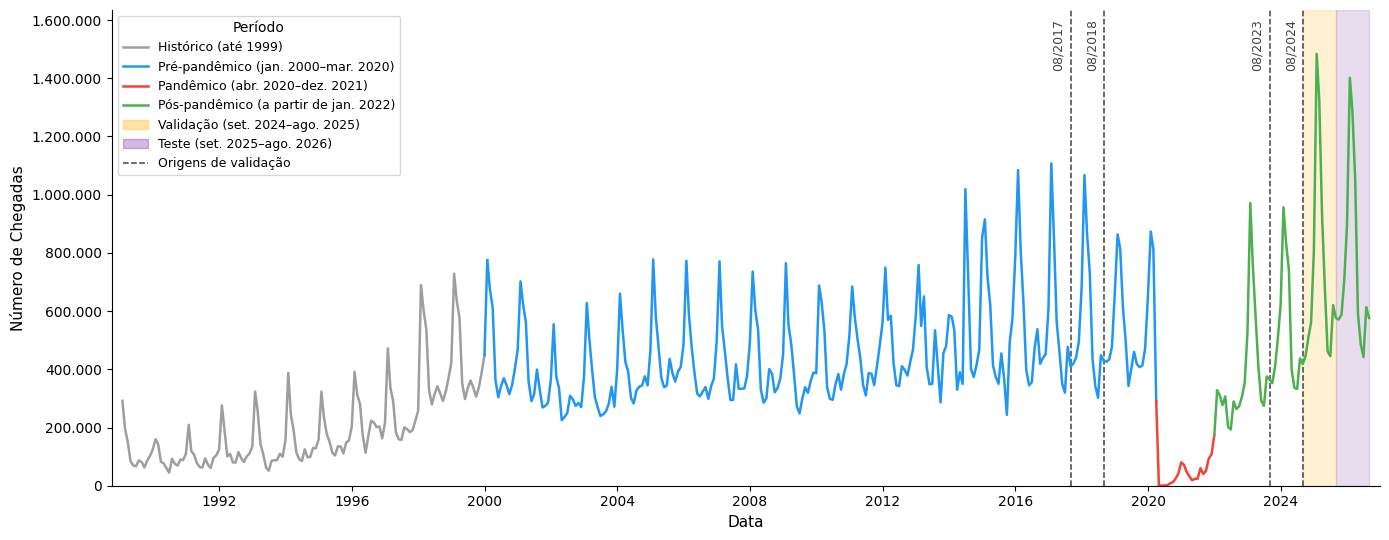

In [4]:
period_colors = {
    'Histórico (até 1999)': '#9e9e9e',
    'Pré-pandêmico (jan. 2000–mar. 2020)': '#2196f3',
    'Pandêmico (abr. 2020–dez. 2021)': '#f44336',
    'Pós-pandêmico (a partir de jan. 2022)': '#4caf50',
}
VAL_COLOR = '#ffb300'
TEST_COLOR = '#6a1b9a'
ORIGIN_COLOR = '#424242'

fig, ax = plt.subplots(figsize=(14, 5.5))

for period, color in period_colors.items():
    segment = figure_df[figure_df['period'] == period]
    ax.plot(segment.index, segment[TARGET], color=color, linewidth=1.8, label=period)

# stitch consecutive segments so there are no visual gaps at boundaries
for i in range(len(figure_df) - 1):
    curr, nxt = figure_df.iloc[i], figure_df.iloc[i + 1]
    if curr['period'] != nxt['period']:
        ax.plot(
            figure_df.index[i : i + 2],
            [curr[TARGET], nxt[TARGET]],
            color=period_colors[nxt['period']],
            linewidth=1.8,
        )

# shaded spans cover whole months: from the end of the previous month
ax.axvspan(train.index[-1], val.index[-1], color=VAL_COLOR, alpha=0.18, zorder=0)
ax.axvspan(val.index[-1], test.index[-1], color=TEST_COLOR, alpha=0.15, zorder=0)

y_top = figure_df[TARGET].max() * 1.08
for origin in ORIGINS:
    ax.axvline(origin, color=ORIGIN_COLOR, linestyle='--', linewidth=1.1, zorder=1)
    ax.text(
        origin - pd.Timedelta(days=60),
        y_top,
        f'{origin:%m/%Y}',
        rotation=90,
        ha='right',
        va='top',
        fontsize=9,
        color=ORIGIN_COLOR,
    )

handles = [
    Line2D([], [], color=color, linewidth=1.8, label=period)
    for period, color in period_colors.items()
] + [
    mpatches.Patch(color=VAL_COLOR, alpha=0.35, label='Validação (set. 2024–ago. 2025)'),
    mpatches.Patch(color=TEST_COLOR, alpha=0.3, label='Teste (set. 2025–ago. 2026)'),
    Line2D(
        [], [], color=ORIGIN_COLOR, linestyle='--', linewidth=1.1,
        label='Origens de validação',
    ),
]
ax.legend(handles=handles, title='Período', loc='upper left', fontsize=9, frameon=True)

ax.set_ylim(0, y_top * 1.02)
ax.set_xlim(figure_df.index[0] - pd.Timedelta(days=120), test.index[-1] + pd.Timedelta(days=120))
ax.set_xlabel('Data', fontsize=11)
ax.set_ylabel('Número de Chegadas', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(thousands))
sns.despine()
plt.tight_layout()
plt.show()

## Figura 2 — Via de Acesso e Países de Origem

Origem: notebook 3, seção *Análise de Variáveis Categóricas*: gráfico de linhas "Chegadas de Turistas por Via de Acesso (2016–2025)" (painel A) e mapa de calor "Média Mensal de Chegadas pelos 10 Principais Países de Origem" (painel B). Ajustes: painéis empilhados, letras A e B no canto superior esquerdo e sem títulos internos.

In [5]:
MONTH_LABELS = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
TOP_N_COUNTRIES = 10

# A: monthly arrivals by access route since 2016
route_time = (
    eda_df[eda_df.index.year >= 2016]
    .groupby(['year_month', 'access_route'], as_index=False)[TARGET]
    .sum()
)

# B: mean monthly arrivals of the top countries (alphabetical order)
top_country_names = (
    eda_df.groupby('origin_country')[TARGET].sum().nlargest(TOP_N_COUNTRIES).index
)
country_month = (
    eda_df[eda_df['origin_country'].isin(top_country_names)]
    .groupby(['origin_country', 'month_num'])[TARGET]
    .mean()
    .unstack('month_num')
)
country_month.columns = MONTH_LABELS

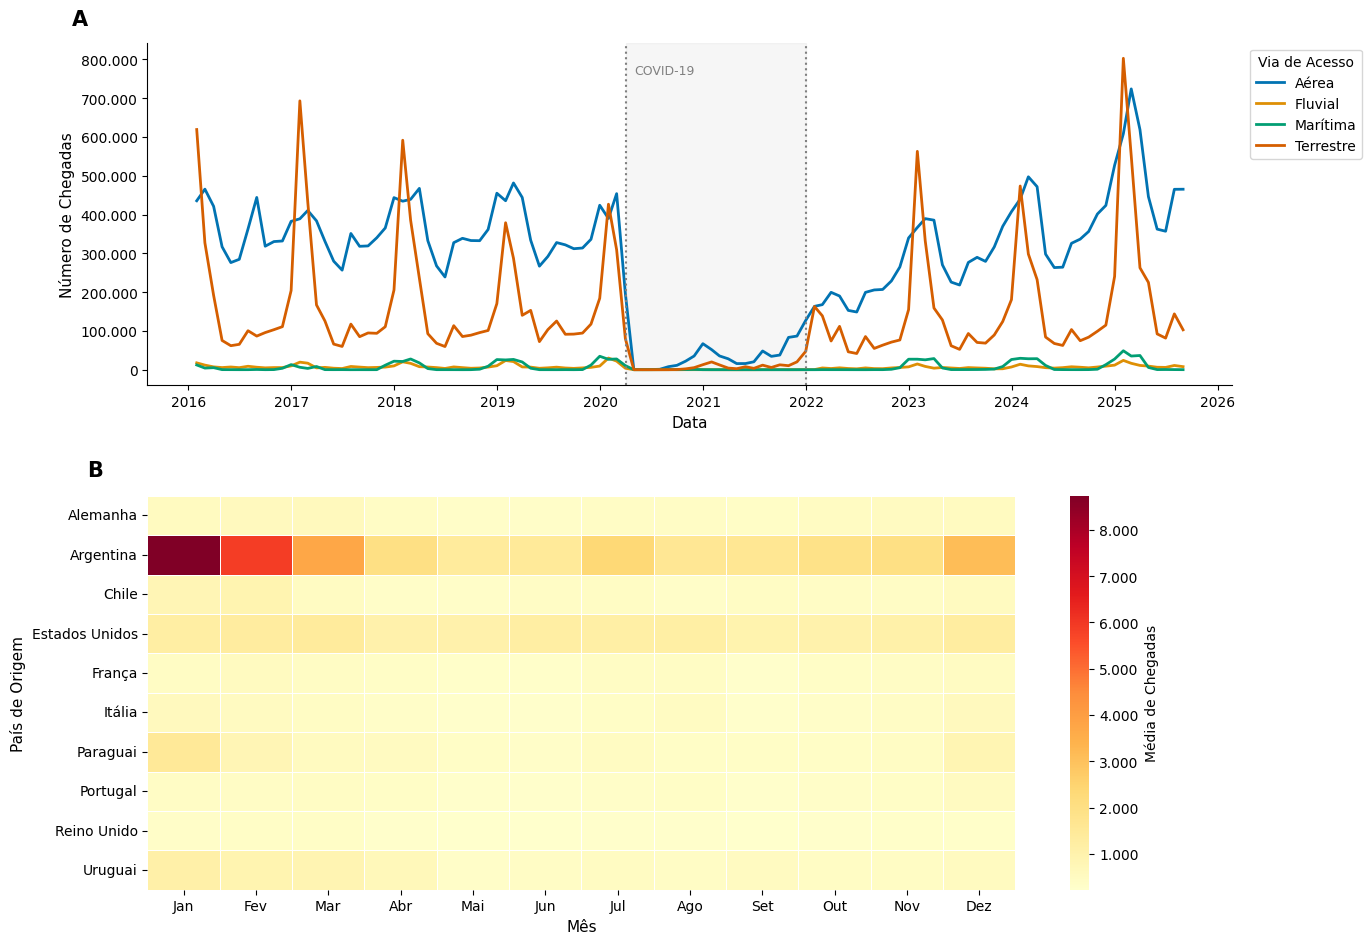

In [6]:
fig, (ax_a, ax_b) = plt.subplots(
    2, 1, figsize=(14, 11), gridspec_kw={'height_ratios': [1, 1.15], 'hspace': 0.3}
)

# ── A: access routes ─────────────────────────────────────────────────────────
sns.lineplot(
    data=route_time, x='year_month', y=TARGET, hue='access_route', linewidth=2, ax=ax_a
)
ax_a.axvline(COVID_START, color='gray', linestyle=':', linewidth=1.5)
ax_a.axvline(COVID_END, color='gray', linestyle=':', linewidth=1.5)
ax_a.axvspan(COVID_START, COVID_END, alpha=0.07, color='gray')
ax_a.text(
    COVID_START + pd.Timedelta(days=30),
    route_time[TARGET].max() * 0.95,
    'COVID-19',
    fontsize=9,
    color='gray',
)
ax_a.set_xlabel('Data', fontsize=11)
ax_a.set_ylabel('Número de Chegadas', fontsize=11)
ax_a.legend(title='Via de Acesso', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)
ax_a.yaxis.set_major_formatter(plt.FuncFormatter(thousands))
sns.despine(ax=ax_a)
panel_letter(ax_a, 'A')

# ── B: top origin countries by month ─────────────────────────────────────────
sns.heatmap(
    country_month,
    linewidths=0.4,
    cmap='YlOrRd',
    ax=ax_b,
    cbar_kws={'label': 'Média de Chegadas', 'format': plt.FuncFormatter(thousands)},
)
ax_b.set_xlabel('Mês', fontsize=11)
ax_b.set_ylabel('País de Origem', fontsize=11)
ax_b.tick_params(axis='y', rotation=0)
panel_letter(ax_b, 'B')

plt.show()

## Figura 3 — Decomposição STL

Origem: notebook 3, seção *Sazonalidade*, figura "Decomposição Sazonal STL (2000–presente)". Ajustes: sem título, rótulos dos painéis em português e marcação dos períodos mantida. Decomposição robusta com período 12 e janela sazonal 13, sobre treino + validação a partir de 2000.

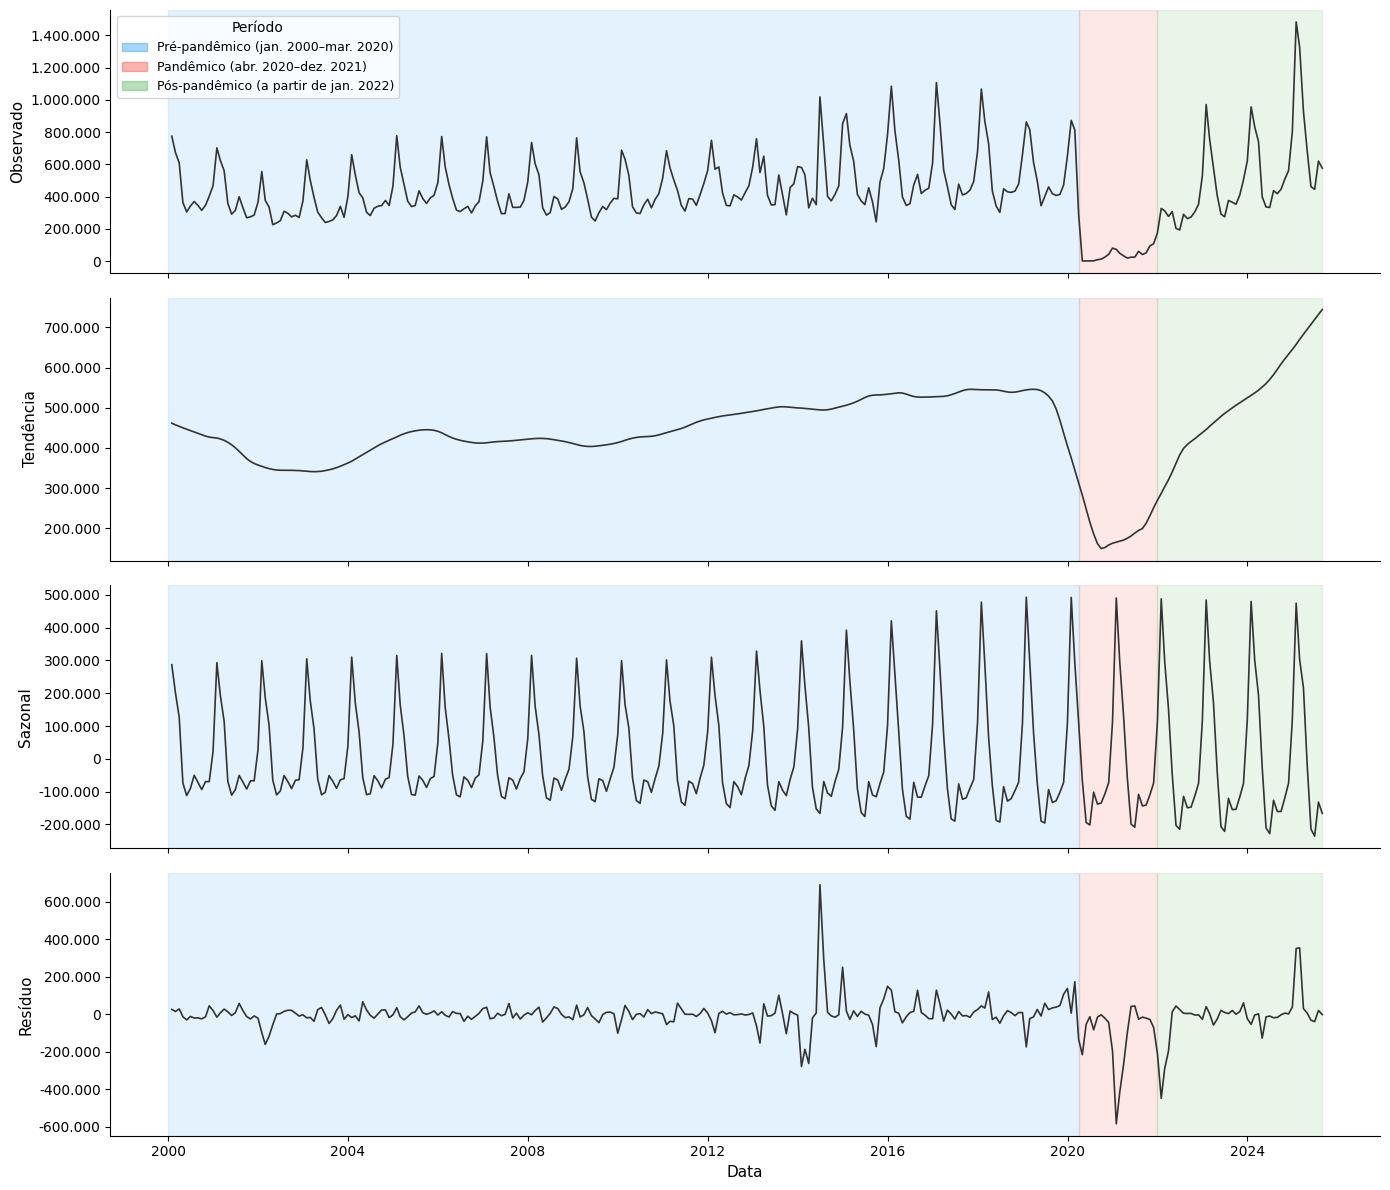

In [7]:
stl_series = pd.concat([train, val]).loc['2000-01-01':]
stl_result = STL(stl_series, period=12, seasonal=13, robust=True).fit()

components = [
    ('Observado', stl_result.observed),
    ('Tendência', stl_result.trend),
    ('Sazonal', stl_result.seasonal),
    ('Resíduo', stl_result.resid),
]
stl_periods = [
    ('Pré-pandêmico (jan. 2000–mar. 2020)', pd.Timestamp('2000-01-01'), COVID_START),
    ('Pandêmico (abr. 2020–dez. 2021)', COVID_START, COVID_END),
    ('Pós-pandêmico (a partir de jan. 2022)', COVID_END, stl_series.index[-1]),
]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

for ax, (label, component) in zip(axes, components):
    ax.plot(component.index, component.values, color='#333333', linewidth=1.2)
    for period, start, end in stl_periods:
        ax.axvspan(start, end, alpha=0.12, color=period_colors[period])
    ax.set_ylabel(label, fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(thousands))
    sns.despine(ax=ax)

axes[0].legend(
    [mpatches.Patch(color=period_colors[p], alpha=0.4) for p, _, _ in stl_periods],
    [p for p, _, _ in stl_periods],
    title='Período',
    loc='upper left',
    frameon=True,
    fontsize=9,
)
axes[-1].set_xlabel('Data', fontsize=11)
plt.tight_layout()
plt.show()

## Figura 4 — Tratamento do Período Pandêmico

Origem: notebook 4, seção *Testes Simples com Dados Pandêmicos*, gráfico "Imputação da lacuna COVID-19 & previsão de Sep 2024–Aug 2025". Ajustes: sem título, legenda em português e, para não poluir a figura, apenas o oráculo, o melhor método de reconstrução (ARIMA progressivo), a combinação dos ARIMAs progressivo e regressivo (pesos lineares de 100% progressivo no início da lacuna a 100% regressivo no fim) e o treino apenas pós-pandemia.

O `auto_arima` e as janelas de treino são os mesmos do notebook 4 (treino de previsão a partir de 2010, imputação ajustada em todo o histórico anterior à lacuna).

In [8]:
RANDOM_STATE = 42
FORECAST_TRAIN_START = pd.Timestamp('2010-01-01')
POST_COVID_TRAIN_START = pd.Timestamp('2022-01-01')


def fit_auto_arima(train_values):
    """The auto-ARIMA of notebook 4 (imputation and validation forecasts)."""
    return auto_arima(
        train_values,
        seasonal=True,
        m=12,
        stepwise=False,
        n_jobs=-1,
        max_p=2,
        max_q=2,
        max_P=2,
        max_Q=2,
        d=1,
        D=0,
        information_criterion='aicc',
        out_of_sample_size=12,
        error_action='ignore',
        suppress_warnings=True,
        random_state=RANDOM_STATE,
    )


def forecast_validation(train_series):
    model = fit_auto_arima(train_series.to_numpy())
    forecast = np.clip(np.asarray(model.predict(n_periods=len(val))), 0, None)
    return pd.Series(forecast, index=val.index)


series = pd.concat([train, val])
covid_mask = (series.index >= COVID_START) & (series.index <= COVID_END)
pre_covid_end = series[series.index < COVID_START].index[-1]
post_covid_start = series[series.index > COVID_END].index[0]

# forward auto-ARIMA imputation: fitted on everything before the gap
fwd_model = fit_auto_arima(series.loc[:pre_covid_end])
imputed_fwd = series.copy()
imputed_fwd[covid_mask] = np.clip(
    np.asarray(fwd_model.predict(n_periods=int(covid_mask.sum()))), 0, None
)

# backward auto-ARIMA: fitted on the reversed post-gap data, forecast back across the gap
bwd_model = fit_auto_arima(series.loc[post_covid_start : train.index[-1]].to_numpy()[::-1])
forecast_bwd = np.asarray(bwd_model.predict(n_periods=int(covid_mask.sum())))[::-1]

# ARIMA blend: 100% forward at the gap start -> 100% backward at the gap end
weights = np.linspace(1.0, 0.0, int(covid_mask.sum()))
imputed_blend = series.copy()
imputed_blend[covid_mask] = np.clip(
    weights * np.asarray(fwd_model.predict(n_periods=int(covid_mask.sum())))
    + (1.0 - weights) * forecast_bwd,
    0,
    None,
)

val_forecasts = {
    'Oracle': forecast_validation(series.loc[FORECAST_TRAIN_START : train.index[-1]]),
    'Auto ARIMA (fwd)': forecast_validation(
        imputed_fwd.loc[FORECAST_TRAIN_START : train.index[-1]]
    ),
    'ARIMA blend': forecast_validation(
        imputed_blend.loc[FORECAST_TRAIN_START : train.index[-1]]
    ),
    'Post-COVID only': forecast_validation(series.loc[POST_COVID_TRAIN_START : train.index[-1]]),
}
for name, forecast in val_forecasts.items():
    errors = val - forecast
    print(
        f'{name:<18} RMSE={np.sqrt(np.mean(errors**2)):>10,.0f}  '
        f'MAPE={np.mean(np.abs(errors / val)) * 100:>6.2f}%'
    )

Oracle             RMSE=   315,692  MAPE= 26.07%
Auto ARIMA (fwd)   RMSE=   347,311  MAPE= 30.52%
ARIMA blend        RMSE=   341,125  MAPE= 29.93%
Post-COVID only    RMSE=   301,951  MAPE= 22.42%


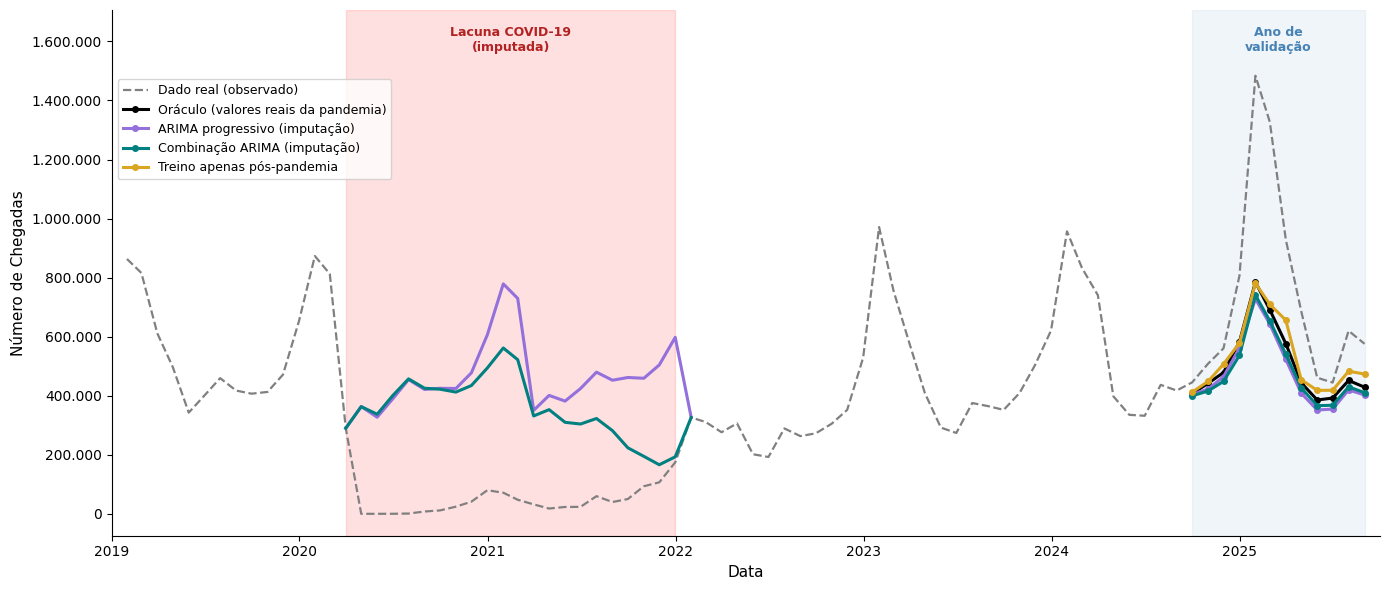

In [9]:
PLOT_START = pd.Timestamp('2019-01-01')
FIG4_STYLES = {
    'Oracle': ('black', 'Oráculo (valores reais da pandemia)'),
    'Auto ARIMA (fwd)': ('mediumpurple', 'ARIMA progressivo (imputação)'),
    'ARIMA blend': ('teal', 'Combinação ARIMA (imputação)'),
    'Post-COVID only': ('goldenrod', 'Treino apenas pós-pandemia'),
}

fig, ax = plt.subplots(figsize=(14, 6))

ax.axvspan(COVID_START, COVID_END, alpha=0.12, color='red', zorder=0)
ax.axvspan(val.index[0], val.index[-1], alpha=0.08, color='steelblue', zorder=0)

trans = ax.get_xaxis_transform()
ax.text(
    COVID_START + (COVID_END - COVID_START) / 2, 0.97, 'Lacuna COVID-19\n(imputada)',
    transform=trans, ha='center', va='top', fontsize=9, color='firebrick', fontweight='bold',
)
ax.text(
    val.index[0] + (val.index[-1] - val.index[0]) / 2, 0.97, 'Ano de\nvalidação',
    transform=trans, ha='center', va='top', fontsize=9, color='steelblue', fontweight='bold',
)

real = series.loc[PLOT_START:]
ax.plot(
    real.index, real.values, color='gray', linewidth=1.6, linestyle='--',
    label='Dado real (observado)', zorder=2,
)

# imputed gaps, with one anchor point on each side for visual continuity
for name, imputed in [('Auto ARIMA (fwd)', imputed_fwd), ('ARIMA blend', imputed_blend)]:
    gap = imputed.loc[pre_covid_end:post_covid_start]
    ax.plot(gap.index, gap.values, color=FIG4_STYLES[name][0], linewidth=2.2, zorder=3)

for name, forecast in val_forecasts.items():
    color, label = FIG4_STYLES[name]
    ax.plot(
        forecast.index, forecast.values, color=color, linewidth=2.2,
        marker='o', markersize=4, label=label, zorder=3,
    )

ax.set_xlabel('Data', fontsize=11)
ax.set_ylabel('Número de Chegadas', fontsize=11)
ax.set_xlim(PLOT_START, val.index[-1] + pd.DateOffset(months=1))
ax.set_ylim(top=real.max() * 1.15)  # room for the span labels
ax.yaxis.set_major_formatter(plt.FuncFormatter(thousands))
ax.legend(loc='upper left', bbox_to_anchor=(0.0, 0.88), fontsize=9, frameon=True)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## Figura 5 — Desempenho na Validação

Origem: notebook 11, *Etapa 1 — Desempenho Geral*, gráficos A e B. Ajustes: os dois gráficos em painéis A e B, nomes das abordagens conforme a Tabela 4 e sem títulos internos.

As previsões de validação são lidas do MLflow como no notebook 11 (a execução mais recente de cada abordagem e a melhor combinação de cada tipo e subconjunto); os ingênuos são reconstruídos em cada origem.

In [10]:
MEMBER_EXPERIMENTS = {
    'SARIMAX': 'Brazil Tourism Forecasting ARIMA',
    'Local ML': 'Brazil Tourism Forecasting ML',
    'Global ML': 'Brazil Tourism Forecasting ML Global',
    'TimesFM': 'Brazil Tourism Forecasting TimesFM',
}
ENSEMBLE_EXPERIMENT = 'Brazil Tourism Forecasting Ensembles'
COMBINATION_TARGETS = [
    ('ensemble', 'all', 'Best ensemble (all)'),
    ('stacking', 'all', 'Best stacking (all)'),
    ('ensemble', 'best_2', 'Best ensemble (best 2)'),
    ('stacking', 'best_2', 'Best stacking (best 2)'),
]
MASE_EXCLUDED = (COVID_START, pd.Timestamp('2022-12-31'))  # as in notebooks 5-11


def experiment_id(name):
    found = mlflow.get_experiment_by_name(name)
    assert found is not None, f'experiment "{name}" not found: run its notebook first'
    return found.experiment_id


def read_forecasts(run):
    path = mlflow.artifacts.download_artifacts(
        run_id=run.info.run_id,
        artifact_path='validation_forecasts.csv',
        dst_path=tempfile.mkdtemp(),
    )
    return pd.read_csv(path, parse_dates=['date'])[['origin', 'date', 'actual', 'forecast']]


frames, configurations = {}, {}
for approach, experiment_name in MEMBER_EXPERIMENTS.items():
    run = client.search_runs(
        [experiment_id(experiment_name)],
        filter_string="tags.role = 'best_validation_forecasts'",
        order_by=['attributes.start_time DESC'],
        max_results=1,
    )[0]
    frames[approach] = read_forecasts(run)
    configurations[approach] = run.data.params['configuration']

# notebook 10: the latest run of each combination, then the best of each kind and subset
latest_per_method = {}
for run in client.search_runs(  # newest first
    [experiment_id(ENSEMBLE_EXPERIMENT)],
    filter_string="tags.role = 'ensemble_validation_forecasts'",
    order_by=['attributes.start_time DESC'],
):
    latest_per_method.setdefault(run.data.params['method'], run)

for kind, subset, approach in COMBINATION_TARGETS:
    candidates = [
        run
        for run in latest_per_method.values()
        if run.data.tags.get('kind') == kind
        and (
            run.data.tags.get('subset')
            or ('best_2' if '(best 2)' in run.data.params['method'] else 'all')
        )
        == subset
    ]
    best = min(candidates, key=lambda run: run.data.metrics['MASE_mean'])
    frames[approach] = read_forecasts(best)
    configurations[approach] = best.data.params['method']

validation = pd.concat(
    [frame.assign(approach=approach) for approach, frame in frames.items()],
    ignore_index=True,
)

# baselines, rebuilt at every origin from the history up to it
history_series = pd.concat([train, val])
VAL_ORIGINS = {
    label: pd.Timestamp(label) + pd.offsets.MonthEnd(0)
    for label in sorted(validation['origin'].unique())
}
baseline_rows = []
for label, origin in VAL_ORIGINS.items():
    dates = pd.date_range(origin + pd.offsets.MonthEnd(1), periods=HORIZON, freq=FREQ)
    actual = history_series.reindex(dates).to_numpy()
    baseline_rows += [
        pd.DataFrame({
            'approach': 'Seasonal naive', 'origin': label, 'date': dates, 'actual': actual,
            'forecast': history_series.reindex(dates - pd.offsets.MonthEnd(12)).to_numpy(),
        }),
        pd.DataFrame({
            'approach': 'Naive', 'origin': label, 'date': dates, 'actual': actual,
            'forecast': history_series.loc[origin],
        }),
    ]
validation = pd.concat([validation, *baseline_rows], ignore_index=True)

assert validation['date'].max() <= val.index[-1], 'a forecast month is after validation'
assert np.allclose(validation['actual'], history_series.reindex(validation['date']).to_numpy())
pd.Series(configurations, name='configuração')

SARIMAX                   SARIMAX(0,1,2)(0,1,1)[12] (last_4y_covid_recov...
Local ML                  XGBoost | seasonal_log_diff | last_4y | keep |...
Global ML                 XGBoost | seasonal_log_diff | last_6y | keep |...
TimesFM                          all | remove | none | calendar | symmetric
Best ensemble (all)                                              mean (all)
Best stacking (all)                                    lasso stacking (all)
Best ensemble (best 2)                                        mean (best 2)
Best stacking (best 2)                              huber stacking (best 2)
Name: configuração, dtype: object

In [11]:
def seasonal_mase_scale(history):
    """In-sample MAE of the seasonal naive (y_t - y_{t-12}), pandemic pairs excluded."""
    diffs = (history - history.shift(12)).abs()
    in_pandemic = history.index.to_series().between(*MASE_EXCLUDED)
    touches = in_pandemic | in_pandemic.shift(12, fill_value=False)
    return float(diffs[~touches.to_numpy()].mean())


MASE_SCALES = {
    label: seasonal_mase_scale(history_series.loc[:origin])
    for label, origin in VAL_ORIGINS.items()
}
validation['abs_scaled_error'] = (
    validation['actual'] - validation['forecast']
).abs() / validation['origin'].map(MASE_SCALES)
mase = validation.groupby(['approach', 'origin'])['abs_scaled_error'].mean().unstack('origin')

# names of Table 4 (the selected configurations are checked against them)
TABLE_NAMES = {
    'Best ensemble (best 2)': 'Média: XGBoost local e SARIMAX',
    'Best stacking (best 2)': 'Huber: XGBoost local e SARIMAX',
    'Best ensemble (all)': 'Média: quatro abordagens',
    'Local ML': 'XGBoost local',
    'SARIMAX': 'SARIMAX',
    'Best stacking (all)': 'Lasso: quatro abordagens',
    'Global ML': 'XGBoost global',
    'TimesFM': 'TimesFM',
    'Seasonal naive': 'Ingênuo sazonal',
    'Naive': 'Ingênuo',
}
assert configurations['Best ensemble (best 2)'] == 'mean (best 2)'
assert configurations['Best stacking (best 2)'] == 'huber stacking (best 2)'
assert configurations['Best ensemble (all)'] == 'mean (all)'
assert configurations['Best stacking (all)'] == 'lasso stacking (all)'
assert configurations['Local ML'].startswith('XGBoost')
assert configurations['Global ML'].startswith('XGBoost')

mase = mase.rename(index=TABLE_NAMES)
mase['Média'] = mase[list(VAL_ORIGINS)].mean(axis=1)
mase['Pior'] = mase[list(VAL_ORIGINS)].max(axis=1)
mase = mase.sort_values('Média')
mase.round(3)

origin,2017-08,2018-08,2023-08,2024-08,Média,Pior
approach,,,,,,
Média: XGBoost local e SARIMAX,0.691,1.014,0.957,1.066,0.932,1.066
Huber: XGBoost local e SARIMAX,0.646,0.988,0.987,1.165,0.946,1.165
Média: quatro abordagens,0.764,0.797,0.856,1.377,0.949,1.377
XGBoost local,0.756,1.063,0.932,1.179,0.982,1.179
SARIMAX,0.723,0.970,1.017,1.258,0.992,1.258
Lasso: quatro abordagens,0.753,0.927,0.939,1.503,1.031,1.503
XGBoost global,1.308,0.591,0.943,1.563,1.101,1.563
TimesFM,0.912,0.701,0.808,2.829,1.312,2.829
Ingênuo sazonal,0.680,0.977,1.463,4.024,1.786,4.024


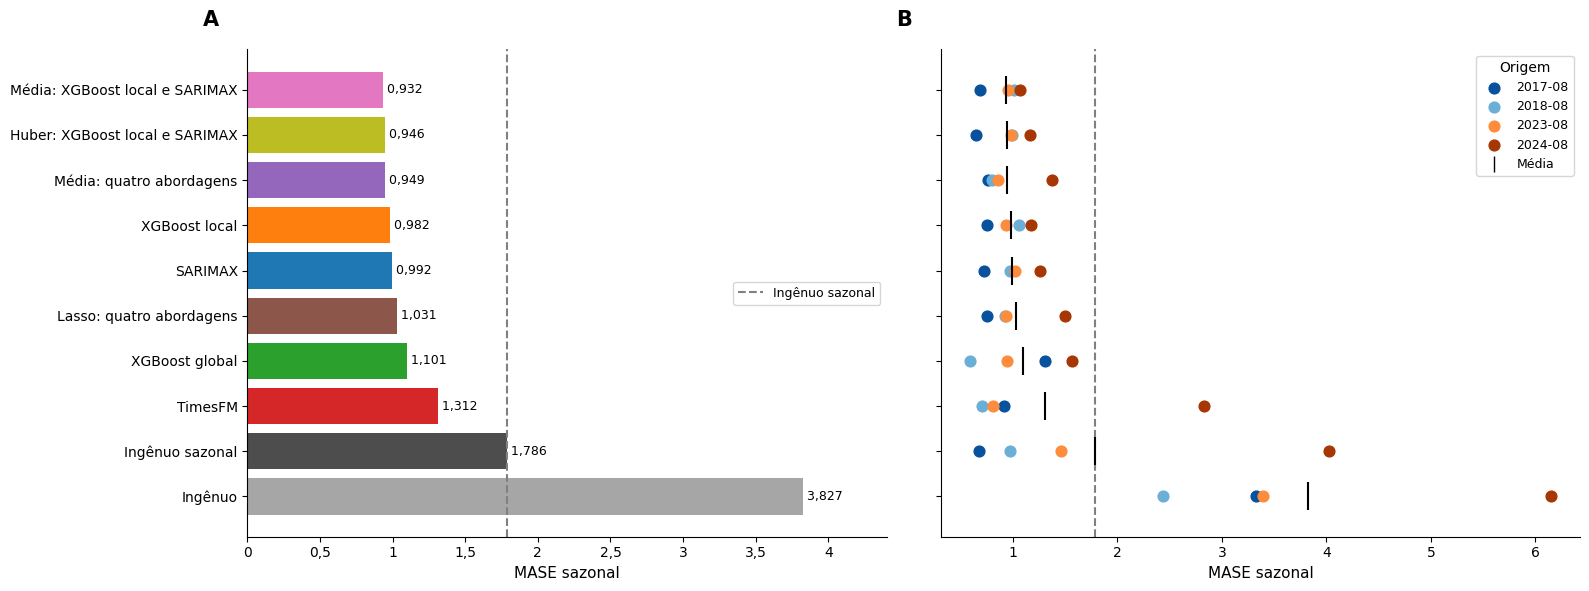

In [12]:
ORIGIN_COLORS = ['#08519c', '#6baed6', '#fd8d3c', '#a63603']
APPROACH_COLORS = {
    'SARIMAX': '#1f77b4',
    'XGBoost local': '#ff7f0e',
    'XGBoost global': '#2ca02c',
    'TimesFM': '#d62728',
    'Média: quatro abordagens': '#9467bd',
    'Lasso: quatro abordagens': '#8c564b',
    'Média: XGBoost local e SARIMAX': '#e377c2',
    'Huber: XGBoost local e SARIMAX': '#bcbd22',
    'Ingênuo sazonal': '#4d4d4d',
    'Ingênuo': '#a6a6a6',
}
order = mase.index[::-1]  # best approach at the top
snaive_mase = mase.loc['Ingênuo sazonal', 'Média']
positions = range(len(order))


def decimal_comma(x, _):
    return f'{x:g}'.replace('.', ',')


fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# ── A: mean seasonal MASE over the four origins ──────────────────────────────
ax_a.barh(order, mase.loc[order, 'Média'], color=[APPROACH_COLORS[a] for a in order])
for i, approach in enumerate(order):
    value = mase.loc[approach, 'Média']
    ax_a.text(value, i, f' {value:.3f}'.replace('.', ','), va='center', fontsize=9)
ax_a.axvline(snaive_mase, color='grey', linestyle='--', label='Ingênuo sazonal')
ax_a.legend(fontsize=9, loc='center right')
ax_a.set_xlim(0, mase['Média'].max() * 1.15)
panel_letter(ax_a, 'A')

# ── B: seasonal MASE at each origin ──────────────────────────────────────────
for color, label in zip(ORIGIN_COLORS, VAL_ORIGINS):
    ax_b.scatter(mase.loc[order, label], positions, color=color, s=60, label=label, zorder=3)
ax_b.scatter(
    mase.loc[order, 'Média'], positions, marker='|', s=400, color='black',
    label='Média', zorder=4,
)
ax_b.axvline(snaive_mase, color='grey', linestyle='--')
handles, labels = ax_b.get_legend_handles_labels()
handles[-1] = Line2D([], [], marker='|', markersize=12, color='black', linestyle='')
ax_b.legend(handles, labels, title='Origem', fontsize=9, loc='upper right')
panel_letter(ax_b, 'B')

for ax in (ax_a, ax_b):
    ax.set_xlabel('MASE sazonal', fontsize=11)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(decimal_comma))
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## Figura 6 — Previsões do Ano de Teste

Origem: notebook 12, seção 6, painéis C (abordagens isoladas) e D (combinações). Ajustes: painéis reetiquetados como A e B, sem títulos internos e legendas em português (nomes da Tabela 5, com o MASE do ano de teste entre parênteses).

As previsões congeladas do ano de teste são lidas do experimento `Brazil Tourism Forecasting Final`, registrado pelo notebook 12. O intervalo de 80% do TimesFM não é registrado, então é recalculado com o pipeline do notebook 12; a mediana recalculada precisa reproduzir a previsão registrada. Usa `TABLE_NAMES`, `APPROACH_COLORS` e `seasonal_mase_scale` da Figura 5.

In [13]:
FINAL_EXPERIMENT = 'Brazil Tourism Forecasting Final'
TIMESFM_EXPERIMENT = 'Brazil Tourism Forecasting TimesFM'
TEST_ORIGIN = val.index[-1]  # the last month the refitted models see

# the latest test run of each approach (notebook 12, section 8)
test_runs = {}
for run in client.search_runs(  # newest first
    [experiment_id(FINAL_EXPERIMENT)],
    filter_string="tags.role = 'test_forecasts'",
    order_by=['attributes.start_time DESC'],
):
    test_runs.setdefault(run.data.tags['approach'], run)
assert set(test_runs) == set(TABLE_NAMES), sorted(test_runs)
fingerprints = {run.data.params['forecasts_fingerprint'] for run in test_runs.values()}
assert len(fingerprints) == 1, 'the test runs come from different executions of notebook 12'


def read_test_forecasts(run):
    path = mlflow.artifacts.download_artifacts(
        run_id=run.info.run_id,
        artifact_path='test_forecasts.csv',
        dst_path=tempfile.mkdtemp(),
    )
    return pd.read_csv(path, parse_dates=['date']).set_index('date')


test_frames = {approach: read_test_forecasts(run) for approach, run in test_runs.items()}
test_forecasts = pd.DataFrame({a: frame['forecast'] for a, frame in test_frames.items()})
test_forecasts.index.freq = None
assert test_forecasts.index.equals(test.index)
for frame in test_frames.values():
    assert np.allclose(frame['actual'], test.to_numpy())

# the 80% interval of TimesFM at the test origin (0.1 and 0.9 quantiles)
timesfm_configuration = test_runs['TimesFM'].data.params['configuration']
timesfm_grid = [
    run
    for run in client.search_runs(
        [experiment_id(TIMESFM_EXPERIMENT)],
        filter_string="attributes.status = 'FINISHED' and params.eval_split = 'validation'",
    )
    if timesfm_zero_shot.Config.from_params(run.data.params).label == timesfm_configuration
]
timesfm_params = timesfm_grid[0].data.params
timesfm_model = timesfm_zero_shot.load_model(timesfm_params['model'])
timesfm_median, timesfm_low, timesfm_high = timesfm_zero_shot.forecast(
    timesfm_model,
    timesfm_zero_shot.Config.from_params(timesfm_params),
    pd.concat([train, val]),
    TEST_ORIGIN,
)
assert np.allclose(timesfm_median.to_numpy(), test_forecasts['TimesFM'].to_numpy(), rtol=1e-6), (
    'the recomputed TimesFM median differs from the logged test forecast'
)

TEST_SCALE = seasonal_mase_scale(pd.concat([train, val]))
test_mase = (test_forecasts.sub(test, axis=0).abs().mean() / TEST_SCALE).rename(TABLE_NAMES)
test_forecasts = test_forecasts.rename(columns=TABLE_NAMES)
coverage = ((test >= timesfm_low) & (test <= timesfm_high)).mean()
print(f'Intervalo de 80% do TimesFM: {coverage:.0%} dos meses de teste cobertos')
pd.DataFrame({
    'MASE (teste)': test_mase,
    'total previsto (milhões)': test_forecasts.sum() / 1e6,
}).sort_values('MASE (teste)').round(3)

Intervalo de 80% do TimesFM: 92% dos meses de teste cobertos


,MASE (teste),total previsto (milhões)
TimesFM,0.767,9.376
Ingênuo sazonal,1.191,8.850
XGBoost global,3.623,11.683
Média: quatro abordagens,3.671,11.717
Ingênuo,4.036,6.913
SARIMAX,4.075,11.992
Média: XGBoost local e SARIMAX,5.410,12.904
Huber: XGBoost local e SARIMAX,5.465,12.941
Lasso: quatro abordagens,5.513,12.974
XGBoost local,6.744,13.815


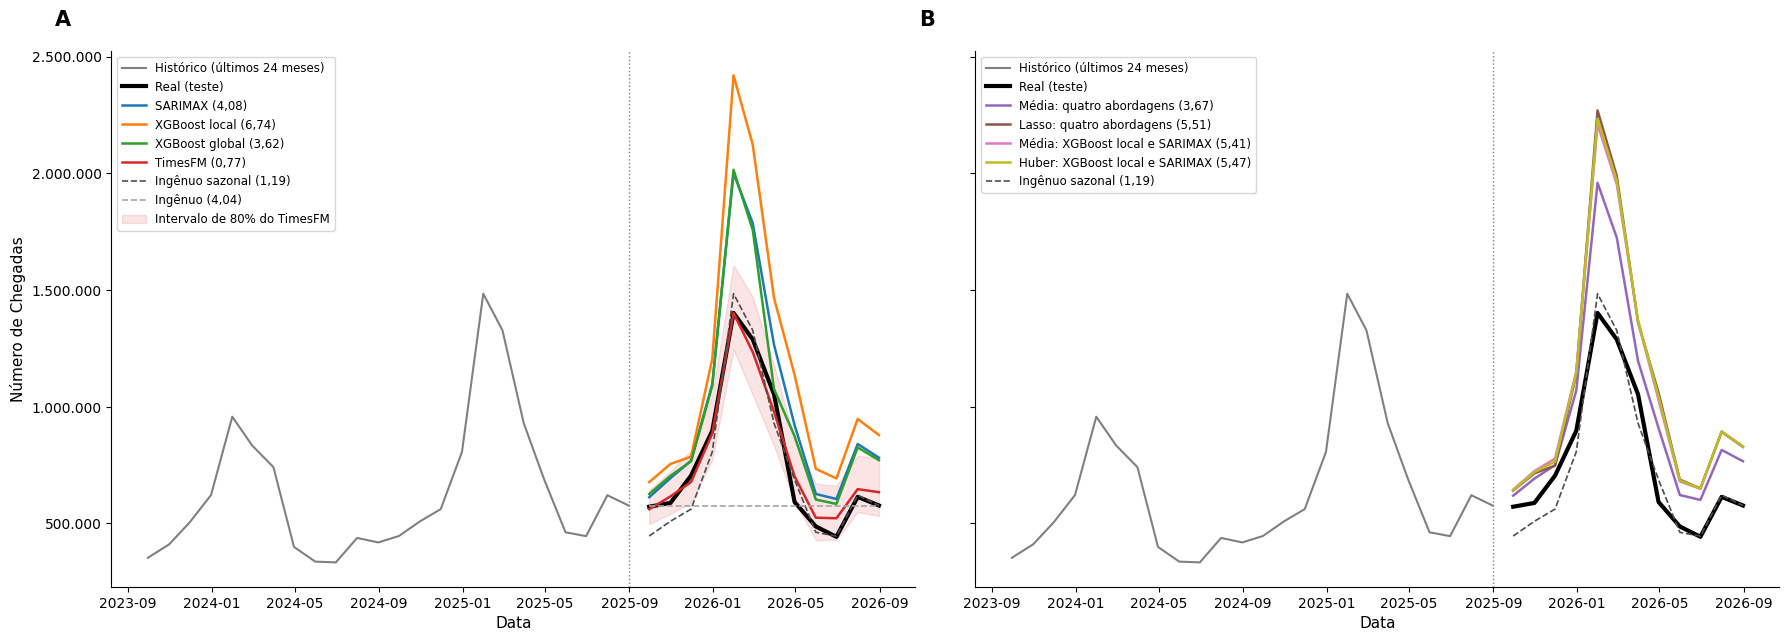

In [14]:
SINGLE = ['SARIMAX', 'XGBoost local', 'XGBoost global', 'TimesFM']
COMBINED = [
    'Média: quatro abordagens',
    'Lasso: quatro abordagens',
    'Média: XGBoost local e SARIMAX',
    'Huber: XGBoost local e SARIMAX',
]
NAIVES = ['Ingênuo sazonal', 'Ingênuo']
panels = [('A', [*SINGLE, *NAIVES]), ('B', [*COMBINED, 'Ingênuo sazonal'])]
recent = pd.concat([train, val]).iloc[-24:]

fig, axes = plt.subplots(1, 2, figsize=(18, 6.5), sharey=True)
for ax, (letter, shown) in zip(axes, panels):
    ax.plot(recent.index, recent, color='grey', linewidth=1.5, label='Histórico (últimos 24 meses)')
    ax.plot(test.index, test, color='black', linewidth=3, label='Real (teste)')
    for approach in shown:
        is_naive = approach in NAIVES
        ax.plot(
            test_forecasts.index,
            test_forecasts[approach],
            color=APPROACH_COLORS[approach],
            linestyle='--' if is_naive else '-',
            linewidth=1.2 if is_naive else 1.8,
            label=f'{approach} ({test_mase[approach]:.2f})'.replace('.', ','),
        )
    if 'TimesFM' in shown:
        ax.fill_between(
            test_forecasts.index,
            timesfm_low,
            timesfm_high,
            color=APPROACH_COLORS['TimesFM'],
            alpha=0.12,
            label='Intervalo de 80% do TimesFM',
        )
    ax.axvline(TEST_ORIGIN, color='grey', linestyle=':', linewidth=1)
    ax.set_xlabel('Data', fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(thousands))
    ax.legend(fontsize=8.5, loc='upper left')
    sns.despine(ax=ax)
    panel_letter(ax, letter)
axes[0].set_ylabel('Número de Chegadas', fontsize=11)
plt.tight_layout()
plt.show()

## Figura 7 — O Ranking de Validação se Manteve?

Origem: notebook 12, seção 7, gráfico de inclinação do MASE de validação para o MASE de teste. Ajustes: sem título, nomes das abordagens conforme as Tabelas 4 e 5 e uma única escala de MASE nos dois lados. Usa o MASE médio de validação da Figura 5 e o MASE de teste da Figura 6.

Correlação de postos (Spearman, 8 modelos): -0.48


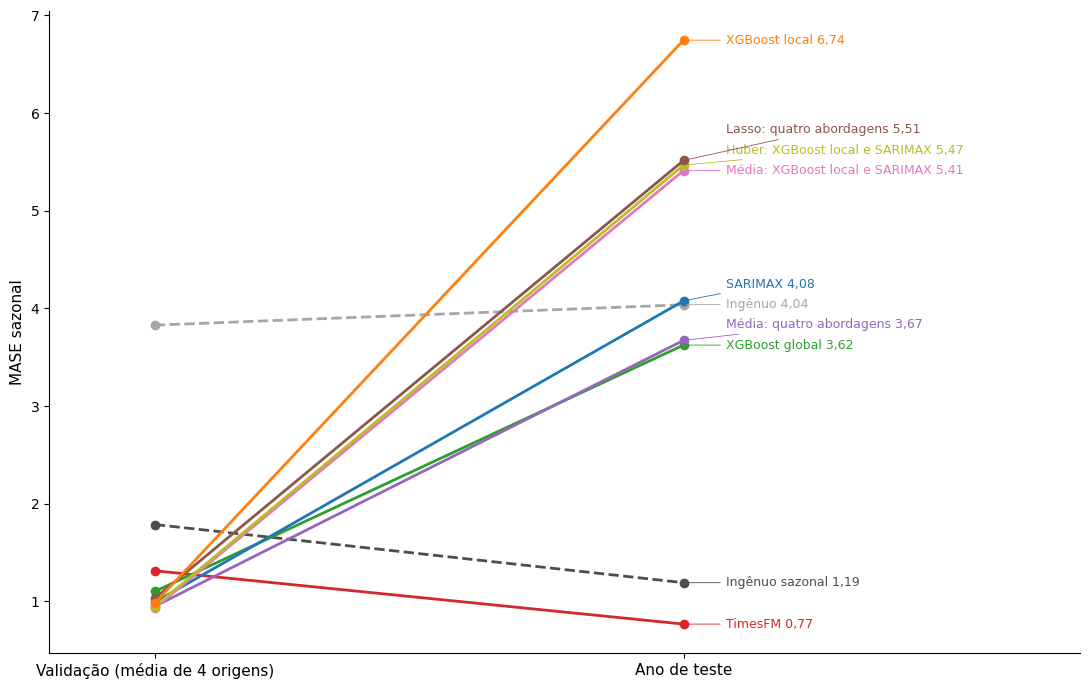

In [15]:
from scipy.stats import spearmanr


def spread_labels(values, min_gap):
    """Label positions at least `min_gap` apart, in the order of the values."""
    positions, last = {}, -np.inf
    for key, value in sorted(values.items(), key=lambda item: item[1]):
        last = max(value, last + min_gap)
        positions[key] = last
    return positions


slope = pd.DataFrame({'validation': mase['Média'], 'test': test_mase}).sort_values('test')
assert slope.notna().all().all()
models = [a for a in slope.index if a not in NAIVES]
rank_correlation = spearmanr(slope.loc[models, 'validation'], slope.loc[models, 'test']).statistic
print(f'Correlação de postos (Spearman, {len(models)} modelos): {rank_correlation:.2f}')

fig, ax = plt.subplots(figsize=(11, 7))
values_range = slope.to_numpy().max() - slope.to_numpy().min()
label_y = spread_labels(slope['test'].to_dict(), min_gap=0.035 * values_range)
for approach, (validation_value, test_value) in slope.iterrows():
    color = APPROACH_COLORS[approach]
    ax.plot(
        [0, 1],
        [validation_value, test_value],
        marker='o',
        color=color,
        linestyle='--' if approach in NAIVES else '-',
        linewidth=2,
    )
    ax.annotate(
        f'{approach} {test_value:.2f}'.replace('.', ','),
        xy=(1, test_value),
        xytext=(1.08, label_y[approach]),
        va='center',
        fontsize=9,
        color=color,
        arrowprops={'arrowstyle': '-', 'color': color, 'lw': 0.6},
    )
ax.set_xticks([0, 1], ['Validação (média de 4 origens)', 'Ano de teste'], fontsize=11)
ax.set_xlim(-0.2, 1.75)
ax.set_ylabel('MASE sazonal', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(decimal_comma))
sns.despine(ax=ax)
plt.tight_layout()
plt.show()